# Rotated Weighted Boxes Fusion example: tennis courts

`weighted_boxes_fusion_rotated` fuses rotated rectangles given as `(cx, cy, w, h, angle)`: center, long edge, short edge and rotation angle in degrees. Unlike the quadrangle version, every box is an exact rectangle.

This notebook:

1. reads the `tennis_courts` image and its labels and draws the labelled rotated boxes,
2. reads simulated predictions of 5 models and draws them,
3. fuses the predictions with `weighted_boxes_fusion_rotated` and draws the fused boxes.

Data used (paths are relative to this notebook):

- `data/images/tennis_courts.jpg`
- `data/labels/labels.csv`
- `data/labels/tennis_courts_predictions.csv`

## Install dependencies

In [1]:
%pip install -q numpy pandas matplotlib pillow
# ensemble_boxes from this repository (the folder above this notebook)
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Imports and settings

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image

from ensemble_boxes import weighted_boxes_fusion_rotated
from ensemble_boxes.ensemble_boxes_wbf_rotated import rotated_box_corners, bb_intersection_over_union_rotated

DATA_DIR = Path('data')
IMAGE_NAME = 'tennis_courts.jpg'
IMAGE_PATH = DATA_DIR / 'images' / IMAGE_NAME
LABELS_PATH = DATA_DIR / 'labels' / 'labels.csv'
PREDICTIONS_PATH = DATA_DIR / 'labels' / '{}_predictions.csv'.format(Path(IMAGE_NAME).stem)

# Columns of a rotated box: center, width (long edge), height (short edge) in pixels, angle in degrees
ROTATED_COLS = ['cx', 'cy', 'w', 'h', 'angle_deg']
# Columns with the 4 corners of a box, in pixels. They are computed from ROTATED_COLS for drawing.
CORNER_COLS = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
# Number of simulated models in the predictions file
N_MODELS = 5

# WBF settings
IOU_THR = 0.55
SKIP_BOX_THR = 0.0

# NMS setting: boxes of one class with IoU above this value count as the same object
NMS_IOU_THR = 0.5

## Helpers

`with_corners` turns rotated boxes into 4 corners, which is what we need to draw them. All pictures in this notebook are then made with the same two functions: `new_figure` shows the image and `draw_quadrangles` draws boxes on top of it.

In [3]:
def with_corners(boxes):
    """
    Add the 4 corners of every rotated box (CORNER_COLS) to the DataFrame.
    The corners are computed from cx, cy, w, h, angle_deg with rotated_box_corners,
    the same function that weighted_boxes_fusion_rotated uses for its IoU.
    """
    corners = np.array([rotated_box_corners(*box).reshape(-1) for box in boxes[ROTATED_COLS].to_numpy(dtype=float)])
    return boxes.assign(**dict(zip(CORNER_COLS, corners.T)))


def new_figure(image, title='', crop=None, figsize=(12, 12)):
    """
    Show the image and return the axes to draw on.
    :param crop: optional (x_min, y_min, x_max, y_max) region to zoom into
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    if crop is not None:
        x_min, y_min, x_max, y_max = crop
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)  # image y axis points down
    ax.set_title(title)
    ax.axis('off')
    return ax


def draw_quadrangles(ax, boxes, color='yellow', color_by=None, legend='', linewidth=1.5,
                     width_by_score=False, show_scores=False):
    """
    Draw every row of `boxes` as a 4-corner polygon.
    :param boxes: DataFrame with CORNER_COLS in pixels
    :param color: color of all boxes, used when color_by is not set
    :param color_by: column name, boxes get one color per value of this column
    :param legend: legend text; with color_by it is put before each value
    :param linewidth: line width of all boxes
    :param width_by_score: make the line wider for boxes with a higher 'score'
    :param show_scores: write the 'score' at the center of each box
    """
    cmap = plt.get_cmap('tab10')
    values = sorted(boxes[color_by].unique()) if color_by else []
    in_legend = set()

    for _, row in boxes.iterrows():
        # 4 corners as a (4, 2) array of (x, y) points
        corners = row[CORNER_COLS].to_numpy(dtype=float).reshape(4, 2)
        if color_by:
            value = row[color_by]
            box_color = cmap(values.index(value) % 10)
            text = '{} {}'.format(legend, value).strip()
        else:
            box_color = color
            text = legend
        # Only the first box of each color goes to the legend
        label = text if text and text not in in_legend else None
        in_legend.add(text)

        width = 0.5 + 1.5 * row['score'] if width_by_score else linewidth
        ax.add_patch(Polygon(corners, closed=True, fill=False, edgecolor=box_color, linewidth=width, label=label))

        if show_scores:
            center_x, center_y = corners.mean(axis=0)
            ax.text(center_x, center_y, '{:.2f}'.format(row['score']), color='black', fontsize=11, ha='center', va='center',
                    bbox=dict(facecolor=box_color, edgecolor='none', pad=2))

    if in_legend - {''}:
        # Legend entries sorted by text, so that models are listed in order
        handles, texts = ax.get_legend_handles_labels()
        order = np.argsort(texts)
        ax.legend([handles[i] for i in order], [texts[i] for i in order], loc='lower left')

## Read and show the image

Image shape (height, width, channels): (1024, 1024, 3)


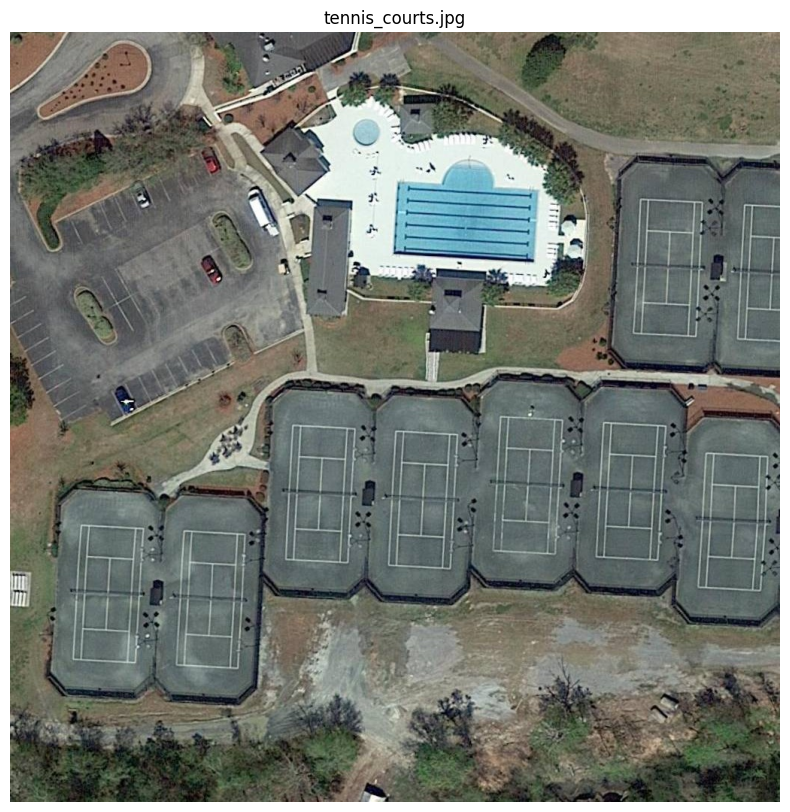

In [4]:
image = np.array(Image.open(IMAGE_PATH).convert('RGB'))
print('Image shape (height, width, channels):', image.shape)

new_figure(image, title=IMAGE_NAME, figsize=(10, 10))
plt.show()

## Read the labels

`labels.csv` has one row per box, for all images. Here we use only the rotated form of each box, in pixels:

- `cx, cy`: center of the box,
- `w, h`: long edge and short edge,
- `angle_deg`: rotation of the long edge from the x axis towards the y axis, in degrees, in the range [-90, 90). The image y axis points down, so a positive angle is a clockwise turn on the screen.

The tennis courts stand almost upright, so their angle is about -87 degrees, close to the -90 / +90 border of the range.

In [5]:
labels = pd.read_csv(LABELS_PATH)

# Keep only the boxes of our image and only the rotated form of the boxes
boxes = labels.loc[labels['image'] == IMAGE_NAME, ['image', 'class_id', 'class_name'] + ROTATED_COLS].reset_index(drop=True)
print('Boxes per class in {}:'.format(IMAGE_NAME))
print(boxes['class_name'].value_counts().to_string())
boxes

Boxes per class in tennis_courts.jpg:
class_name
tennis court     8
small vehicle    4
swimming pool    1


,image,class_id,class_name,cx,cy,w,h,angle_deg
0,tennis_courts.jpg,10,small vehicle,153.0,491.0,39.8,18.8,62.1
1,tennis_courts.jpg,10,small vehicle,267.5,171.5,38.3,19.7,64.1
2,tennis_courts.jpg,10,small vehicle,268.5,319.0,35.8,18.0,59.0
3,tennis_courts.jpg,10,small vehicle,175.5,221.0,28.1,16.2,69.0
4,tennis_courts.jpg,14,swimming pool,608.5,234.5,188.3,133.2,3.0
5,tennis_courts.jpg,4,tennis court,873.5,313.6,180.2,86.2,-86.5
6,tennis_courts.jpg,4,tennis court,962.0,651.8,182.2,89.2,-87.2
7,tennis_courts.jpg,4,tennis court,826.5,611.5,181.5,86.1,-87.2
8,tennis_courts.jpg,4,tennis court,689.5,603.0,181.1,86.2,-86.5
9,tennis_courts.jpg,4,tennis court,551.0,622.0,181.5,86.2,-86.8


## Draw the labels on the image

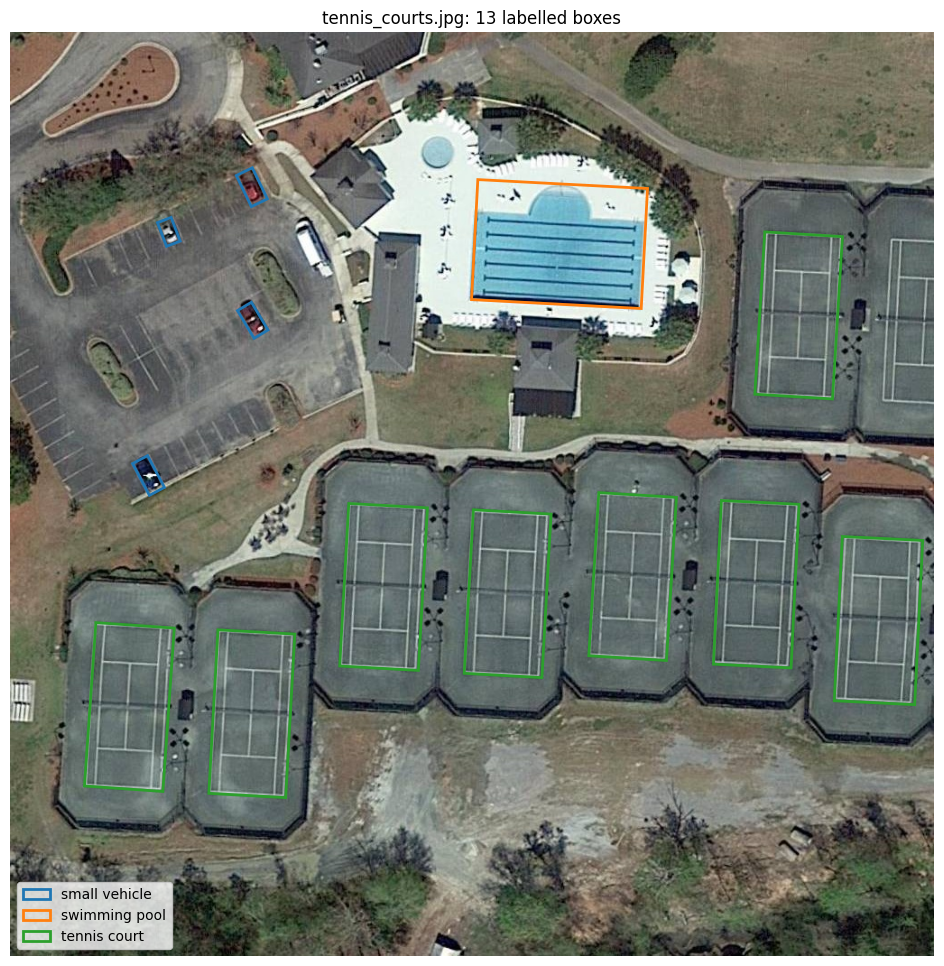

In [6]:
ax = new_figure(image, title='{}: {} labelled boxes'.format(IMAGE_NAME, len(boxes)))
draw_quadrangles(ax, with_corners(boxes), color_by='class_name', linewidth=2)
plt.show()

## Load the predictions

There are no real model outputs for this image, so the predictions are simulated from the labels: each labelled object has 3 to 5 predictions, as if it was detected by 3 to 5 out of 5 different models. Every prediction is the labelled box with a slightly different center, size and angle, and its confidence score is higher when it is closer to the label.

The predictions are read from `labels/tennis_courts_predictions.csv`. The notebook does not write this file. How the file was created is described in the appendix at the end.

`object_id` and `label_error` come from the labels and are kept only to check the result; a real model would not output them.

In [7]:
predictions = pd.read_csv(PREDICTIONS_PATH)
print('Loaded {} predictions from {}'.format(len(predictions), PREDICTIONS_PATH))

print('Objects: {}, predictions: {}'.format(len(boxes), len(predictions)))
print(predictions.groupby('object_id').size().value_counts().sort_index().to_string())
print('Score: min {:.2f}, mean {:.2f}, max {:.2f}'.format(predictions['score'].min(), predictions['score'].mean(), predictions['score'].max()))
predictions.head(8)

Loaded 55 predictions from data/labels/tennis_courts_predictions.csv
Objects: 13, predictions: 55
3    3
4    4
5    6
Score: min 0.30, mean 0.68, max 0.91


,image,object_id,model,class_id,class_name,score,label_error,cx,cy,w,h,angle_deg
0,tennis_courts.jpg,0,2,10,small vehicle,0.547,0.0904,154.0,488.9,37.7,18.9,61.2
1,tennis_courts.jpg,0,3,10,small vehicle,0.714,0.0601,152.1,492.0,41.0,18.8,65.5
2,tennis_courts.jpg,0,4,10,small vehicle,0.758,0.0473,152.1,491.4,38.3,19.5,62.0
3,tennis_courts.jpg,1,0,10,small vehicle,0.527,0.0921,268.1,171.9,38.9,20.0,70.5
4,tennis_courts.jpg,1,1,10,small vehicle,0.762,0.0425,266.9,170.6,39.2,20.6,63.8
5,tennis_courts.jpg,1,2,10,small vehicle,0.752,0.0509,266.6,172.2,39.4,20.1,62.1
6,tennis_courts.jpg,1,3,10,small vehicle,0.813,0.0378,267.6,171.7,39.6,19.9,66.1
7,tennis_courts.jpg,1,4,10,small vehicle,0.747,0.0467,267.8,172.2,36.1,19.4,62.7


## Show the predictions

Predictions are colored by model. Line width grows with the confidence score. The second picture zooms into three tennis courts, with the labels drawn in white for comparison.

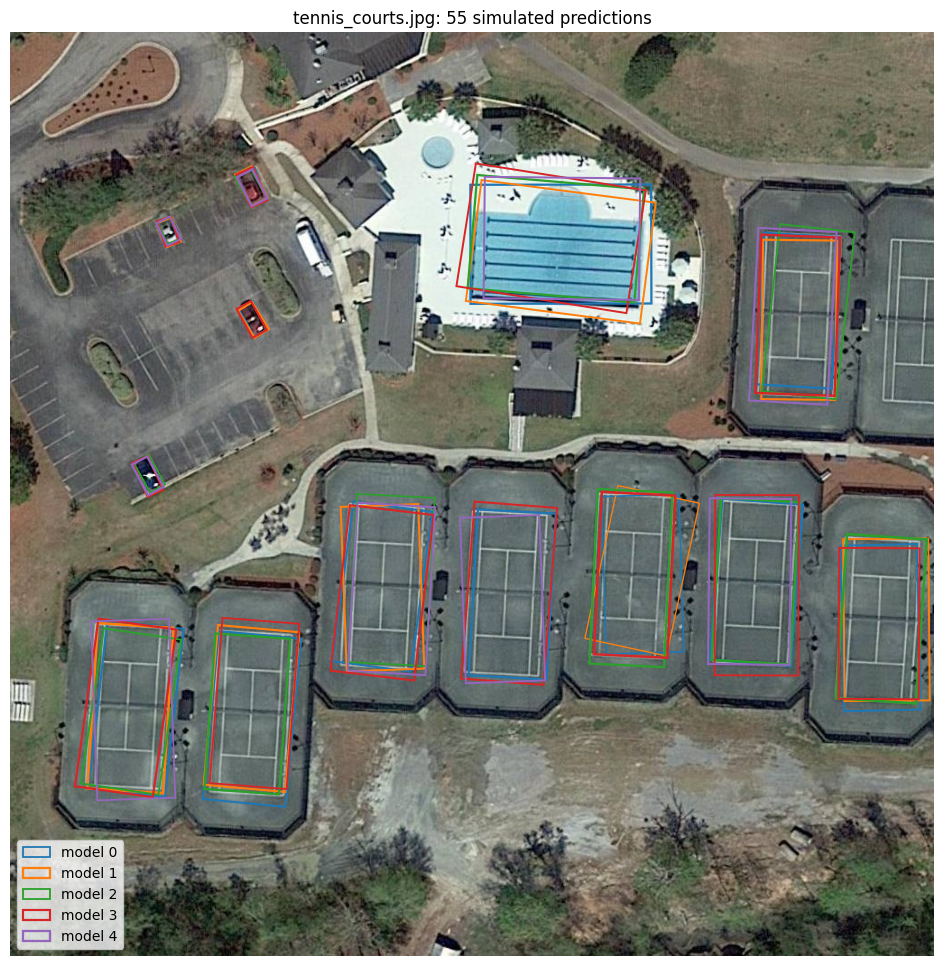

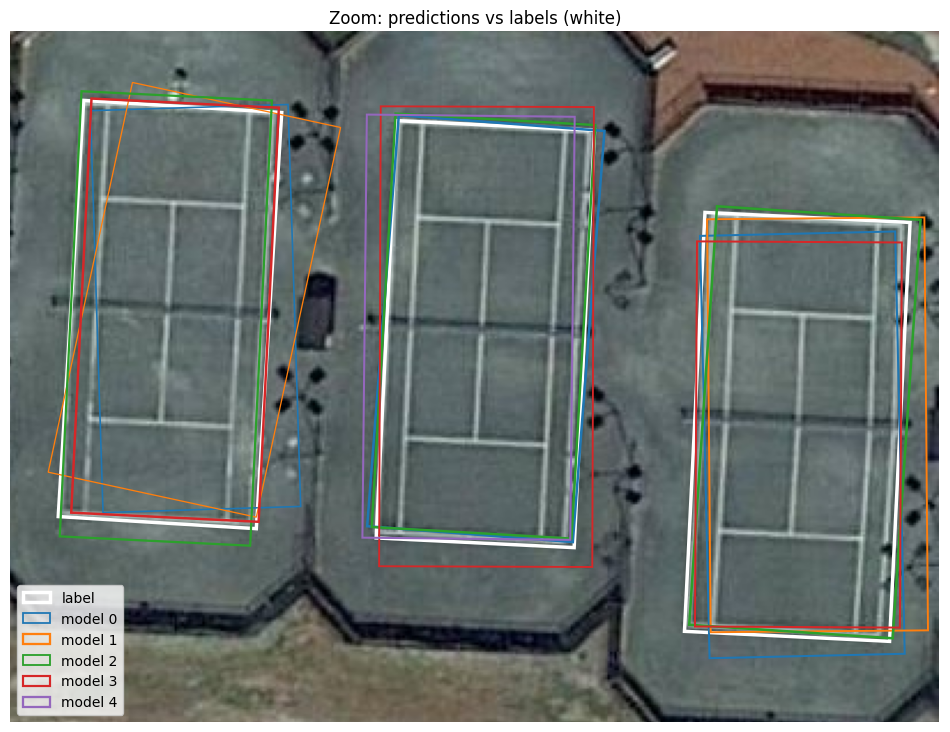

In [8]:
ax = new_figure(image, title='{}: {} simulated predictions'.format(IMAGE_NAME, len(predictions)))
draw_quadrangles(ax, with_corners(predictions), color_by='model', legend='model', width_by_score=True)
plt.show()

ax = new_figure(image, title='Zoom: predictions vs labels (white)', crop=(620, 480, 1024, 780), figsize=(12, 9))
draw_quadrangles(ax, with_corners(boxes), color='white', legend='label', linewidth=2.5)
draw_quadrangles(ax, with_corners(predictions), color_by='model', legend='model', width_by_score=True)
plt.show()

## Angles on both sides of the -90 / +90 border

The tennis court labels are at about -87 degrees. A prediction turned a few degrees further goes below -90 and is stored as an angle near +90, which is the same rectangle. So the predictions of one court can have angles like -88 and +89. A plain average of these would be close to 0, a box lying on its side. `weighted_boxes_fusion_rotated` handles this border correctly.

In [9]:
court_predictions = predictions[predictions['class_name'] == 'tennis court']
print('Tennis court predictions: {}'.format(len(court_predictions)))
print('  with a negative angle: {}'.format((court_predictions['angle_deg'] < 0).sum()))
print('  with a positive angle: {}'.format((court_predictions['angle_deg'] > 0).sum()))
print()
print('Predictions of one court (object 6):')
predictions.loc[predictions['object_id'] == 6, ['model', 'score'] + ROTATED_COLS]

Tennis court predictions: 34
  with a negative angle: 28
  with a positive angle: 6

Predictions of one court (object 6):


,model,score,cx,cy,w,h,angle_deg
26,0,0.632,964.2,659.6,183.5,84.8,88.7
27,1,0.596,970.8,650.9,179.4,94.4,89.5
28,2,0.886,965.3,649.8,182.2,88.6,-86.2
29,3,0.620,962.5,655.1,167.3,89.0,-89.7


## Weighted Boxes Fusion for rotated boxes

`weighted_boxes_fusion_rotated` takes one list of boxes, scores and labels per model. Each box is 5 numbers `(cx, cy, w, h, angle)`.

`cx, cy, w, h` must be normalized to [0, 1] by **one scale for both axes**, here the longer side of the image. Dividing x by the width and y by the height separately would stretch a rotated rectangle into a parallelogram on a non-square image. The angle stays in degrees. The fused boxes are converted back to pixels with the same scale.

Boxes of the same class that overlap with rotated IoU above `iou_thr` are fused into one box, with center, size and angle averaged using the scores as weights.

In [10]:
def fuse_predictions(predictions, image_shape, iou_thr=IOU_THR, skip_box_thr=SKIP_BOX_THR, n_models=N_MODELS):
    """
    Run rotated WBF on a predictions DataFrame.
    :return: DataFrame with one row per fused box, cx, cy, w, h in pixels and angle in degrees
    """
    # One scale for x and y: the longer side of the image. The angle is not scaled.
    scale = float(max(image_shape[:2]))
    to_normalized = np.array([scale, scale, scale, scale, 1.0])

    # One list of boxes, scores and labels per model
    boxes_list, scores_list, labels_list = [], [], []
    for model in range(n_models):
        model_preds = predictions[predictions['model'] == model]
        boxes_list.append((model_preds[ROTATED_COLS].to_numpy(dtype=float) / to_normalized).tolist())
        scores_list.append(model_preds['score'].tolist())
        labels_list.append(model_preds['class_id'].tolist())

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion_rotated(
        boxes_list, scores_list, labels_list, weights=None, iou_thr=iou_thr, skip_box_thr=skip_box_thr)

    fused = pd.DataFrame(np.asarray(fused_boxes) * to_normalized, columns=ROTATED_COLS).round(1)
    fused.insert(0, 'score', np.round(fused_scores, 3))
    fused.insert(0, 'class_id', np.asarray(fused_labels).astype(int))
    return fused


fused = fuse_predictions(predictions, image.shape)
# Class names for the legend
fused.insert(1, 'class_name', fused['class_id'].map(dict(zip(boxes['class_id'], boxes['class_name']))))
print('{} predictions were fused into {} boxes'.format(len(predictions), len(fused)))
fused

55 predictions were fused into 13 boxes


,class_id,class_name,score,cx,cy,w,h,angle_deg
0,10,small vehicle,0.721,175.2,220.6,28.1,16.0,68.2
1,10,small vehicle,0.720,267.4,171.7,38.6,20.0,64.7
2,4,tennis court,0.706,873.7,312.9,178.7,85.0,-87.1
3,4,tennis court,0.683,133.7,749.8,185.7,85.7,-84.9
4,14,swimming pool,0.665,607.0,232.4,188.9,132.7,4.2
5,4,tennis court,0.600,415.8,615.2,183.6,88.0,-86.3
6,4,tennis court,0.582,824.8,609.3,184.4,89.6,-87.6
7,4,tennis court,0.547,965.6,653.5,178.5,89.1,-89.1
8,4,tennis court,0.535,266.7,752.5,179.8,87.6,-85.3
9,4,tennis court,0.468,693.2,601.5,182.5,84.2,-86.9


## Fused boxes

The image again, now with the fused boxes, colored by class. The number in each box is its fused confidence score.

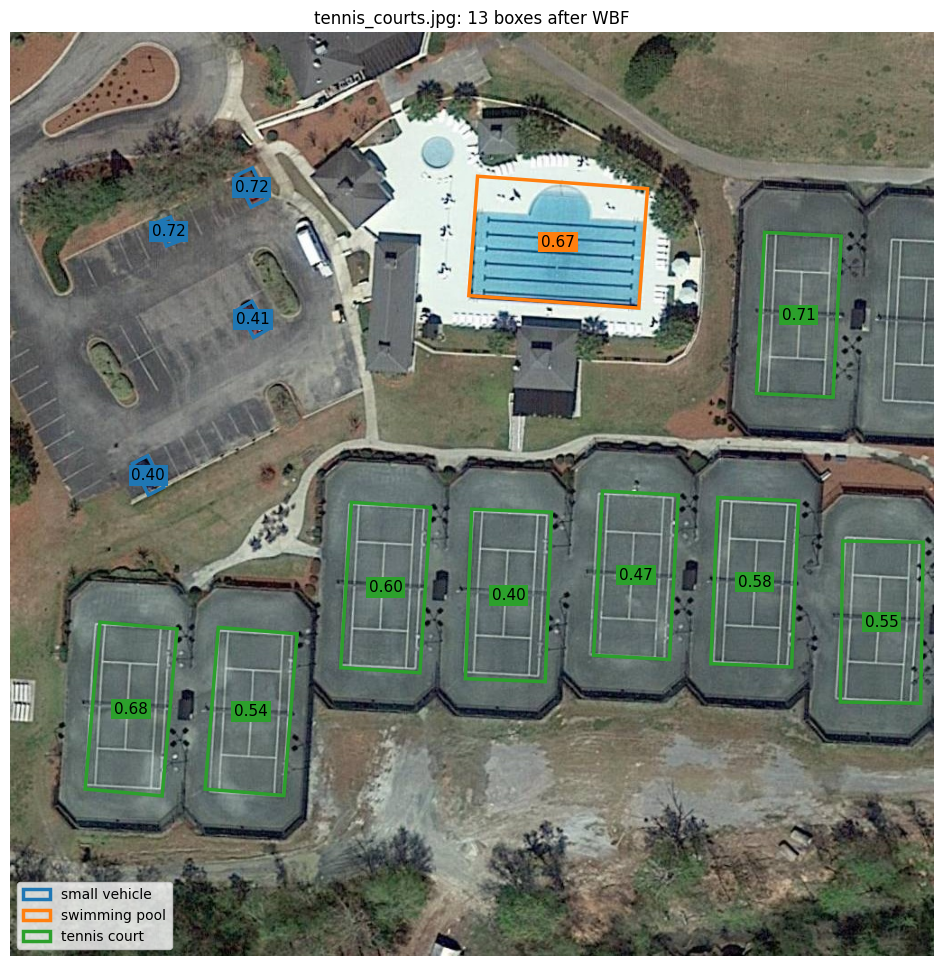

In [11]:
ax = new_figure(image, title='{}: {} boxes after WBF'.format(IMAGE_NAME, len(fused)))
draw_quadrangles(ax, with_corners(fused), color_by='class_name', linewidth=2.5, show_scores=True)
plt.show()

## Non-maximum suppression (NMS) for comparison

NMS is the usual alternative to WBF. For every group of overlapping boxes of one class it keeps the box with the highest score and throws the others away. WBF instead averages all boxes of the group.

The `nms` function of `ensemble_boxes` works only with axis-aligned boxes `(x1, y1, x2, y2)`, so for rotated boxes we use a short NMS written here. It measures the overlap with `bb_intersection_over_union_rotated`, the same IoU that `weighted_boxes_fusion_rotated` uses.

In [12]:
def nms_predictions(predictions, iou_thr=NMS_IOU_THR):
    """
    Non-maximum suppression for rotated boxes, done separately for each class.
    :param iou_thr: a box is dropped when its IoU with an already kept box is above this value
    :return: DataFrame with the kept predictions, unchanged, best score first
    """
    kept = []
    for class_id, group in predictions.groupby('class_id'):
        # Boxes of one class, best score first
        group = group.sort_values('score', ascending=False)
        coords = group[ROTATED_COLS].to_numpy(dtype=float)
        remaining = list(range(len(group)))
        while remaining:
            # The best remaining box is kept ...
            best = remaining.pop(0)
            kept.append(group.index[best])
            # ... and every box that overlaps it too much is dropped
            remaining = [i for i in remaining if bb_intersection_over_union_rotated(coords[best], coords[i]) <= iou_thr]
    return predictions.loc[kept].sort_values('score', ascending=False).reset_index(drop=True)


nms_boxes = nms_predictions(predictions)
print('NMS kept {} of {} predictions'.format(len(nms_boxes), len(predictions)))
nms_boxes[['model', 'class_name', 'score'] + ROTATED_COLS]

NMS kept 13 of 55 predictions


,model,class_name,score,cx,cy,w,h,angle_deg
0,1,tennis court,0.905,133.0,748.8,183.5,84.1,-86.4
1,2,tennis court,0.886,965.3,649.8,182.2,88.6,-86.2
2,0,tennis court,0.882,826.7,609.1,179.1,89.6,-85.6
3,1,small vehicle,0.876,175.5,221.4,28.6,16.6,68.7
4,3,tennis court,0.842,691.7,601.1,180.1,81.5,-87.2
5,3,tennis court,0.832,872.7,313.4,175.5,87.7,-87.9
6,3,small vehicle,0.813,267.6,171.7,39.6,19.9,66.1
7,1,small vehicle,0.771,269.3,318.6,35.1,18.6,58.4
8,0,tennis court,0.767,556.1,622.8,184.1,86.4,-86.8
9,2,tennis court,0.758,262.5,755.2,172.7,83.0,-85.9


## Boxes kept by NMS

The image with the boxes kept by NMS. Each of them is one of the original predictions, with its original score written in the box. These scores are higher than the WBF scores because WBF lowers the score of a box that was not found by all 5 models.

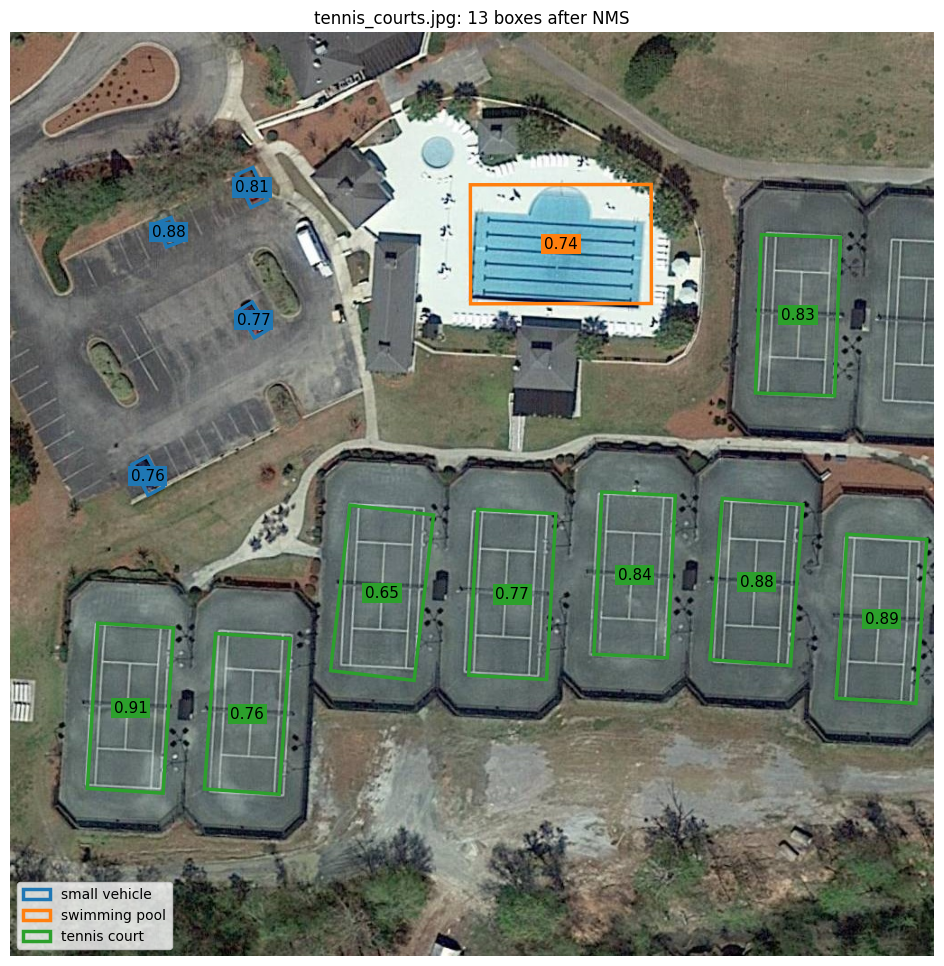

In [13]:
ax = new_figure(image, title='{}: {} boxes after NMS'.format(IMAGE_NAME, len(nms_boxes)))
draw_quadrangles(ax, with_corners(nms_boxes), color_by='class_name', linewidth=2.5, show_scores=True)
plt.show()

## Appendix: how the predictions file was generated

The function below was used once, as `generate_predictions(boxes)`, to create `tennis_courts_predictions.csv`. Every prediction is the labelled rotated box with:

- a small random shift of the center,
- a small random change of the width and of the height,
- a random change of the angle of a few degrees,
- a confidence score that is higher when the prediction is closer to the label (`label_error` is the mean distance between matching corners, as a fraction of the box size).

The shift is proportional to the box size, so small vehicles and large tennis courts are disturbed to a similar degree.

The function is kept here for reference and is not called, so that the notebook always shows the same predictions.

In [14]:
def generate_predictions(boxes, min_preds=3, max_preds=5, n_models=N_MODELS,
                         shift_std=0.04, size_std=0.04, angle_std=3.0, score_drop=5.0, score_noise=0.03,
                         score_range=(0.3, 0.99), seed=42):
    """
    Simulate model predictions from labelled rotated boxes.
    :param boxes: labels of one image with cx, cy, w, h in pixels and angle_deg
    :param min_preds, max_preds: number of predictions generated per object
    :param n_models: number of simulated models, each predicts an object at most once
    :param shift_std: std of the shift of the center, as a fraction of the box size
    :param size_std: std of the relative change of w and of h
    :param angle_std: std of the change of the angle, in degrees
    :param score_drop: how fast the score falls as the prediction moves away from the label:
        score = 1 - score_drop * label_error
    :param score_noise: std of the random noise added to the score
    :param score_range: scores are clipped to this range
    :return: DataFrame with one row per prediction
    """
    rng = np.random.default_rng(seed)
    rows = []
    for object_id, row in boxes.iterrows():
        # Box size in pixels: side of a square with the same area
        size = np.sqrt(row['w'] * row['h'])
        label_corners = rotated_box_corners(row['cx'], row['cy'], row['w'], row['h'], row['angle_deg'])

        # Pick which models "detected" this object: 3 to 5 different models
        n_preds = rng.integers(min_preds, max_preds + 1)
        models = np.sort(rng.choice(n_models, size=n_preds, replace=False))

        for model in models:
            cx = row['cx'] + rng.normal(0, shift_std * size)
            cy = row['cy'] + rng.normal(0, shift_std * size)
            w = row['w'] * (1 + rng.normal(0, size_std))
            h = row['h'] * (1 + rng.normal(0, size_std))
            angle = row['angle_deg'] + rng.normal(0, angle_std)

            # How far the prediction is from the label: mean distance between matching
            # corners, as a fraction of the box size (0 = exactly on the label)
            pred_corners = rotated_box_corners(cx, cy, w, h, angle)
            label_error = np.linalg.norm(pred_corners - label_corners, axis=1).mean() / size
            # The closer to the label, the higher the score, plus a little noise
            score = 1.0 - score_drop * label_error + rng.normal(0, score_noise)
            score = float(np.clip(score, *score_range))

            # Keep the angle in [-90, 90). An angle that went below -90 comes back near +90:
            # it is the same rectangle, because a rectangle looks the same after a 180 degree turn.
            angle = (angle + 90) % 180 - 90
            rows.append({
                'image': row['image'],
                'object_id': object_id,
                'model': int(model),
                'class_id': row['class_id'],
                'class_name': row['class_name'],
                'score': round(score, 3),
                'label_error': round(float(label_error), 4),
                'cx': round(cx, 1), 'cy': round(cy, 1), 'w': round(w, 1), 'h': round(h, 1), 'angle_deg': round(angle, 1),
            })
    return pd.DataFrame(rows)